# **scRNA-seq Pipeline**

## Pre-process

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap.umap_ as umap
from sklearn.cluster import KMeans



data = pd.read_csv('MessmerESCData.csv')

data.head() # rows = cells, cols = genes (as expected for scRNA-seq)

,Unnamed: 0,lane1_3600STDY6077864_ATCACGTT_L001_15986_1,lane1_3600STDY6077865_CGATGTTT_L001_15986_1,lane1_3600STDY6077866_TTAGGCAT_L001_15986_1,lane1_3600STDY6077867_TGACCACT_L001_15986_1,lane1_3600STDY6077868_ACAGTGGT_L001_15986_1,lane1_3600STDY6077869_GCCAATGT_L001_15986_1,lane1_3600STDY6077870_CAGATCTG_L001_15986_1,lane1_3600STDY6077871_ACTTGATG_L001_15986_1,lane1_3600STDY6077872_GATCAGCG_L001_15986_1,...,lane1_3600STDY6184171_ACAGAAGA_L001_17592_1,lane1_3600STDY6184172_CGACCCTT_L001_17592_1,lane1_3600STDY6184173_CTGCCTAG_L001_17592_1,lane1_3600STDY6184174_GAGCGCAT_L001_17592_1,lane1_3600STDY6184175_AACTTATC_L001_17592_1,lane1_3600STDY6184176_CCGATGTA_L001_17592_1,lane1_3600STDY6184177_TTACTACC_L001_17592_1,lane1_3600STDY6184178_CAAGGAGC_L001_17592_1,lane1_3600STDY6184179_TGGTTGAC_L001_17592_1,lane1_3600STDY6184180_ACCTGCTG_L001_17592_1
0,ENSG00000223972,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,ENSG00000227232,0,0,0,0,3,2,1,1,0,...,0,0,1,0,0,0,0,0,0,0
2,ENSG00000278267,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,ENSG00000243485,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,ENSG00000284332,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [5]:
# Organize and cast types
cells = data[['Unnamed: 0']].rename(columns={'Unnamed: 0':'cell'})
gene_expression = data.loc[:, data.columns != 'Unnamed: 0'].astype(int)

# Log-Normalize
log_gene = gene_expression.apply(lambda x: np.log(1+x))

# Standardize
scaler = StandardScaler()
scaled_data = scaler.fit_transform(log_gene)

## Dimensionality Reduction

**Principal Component Analysis**

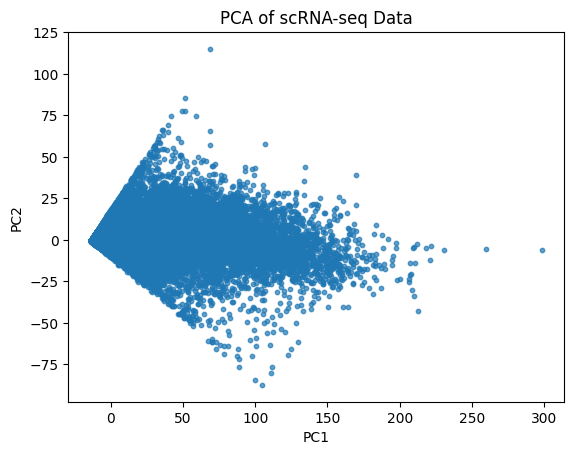

In [6]:
# PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_data)

# Visualize
plt.scatter(pca_result[:,0], pca_result[:,1], s=10, alpha=0.7)
plt.title("PCA of scRNA-seq Data")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

**t-SNE**

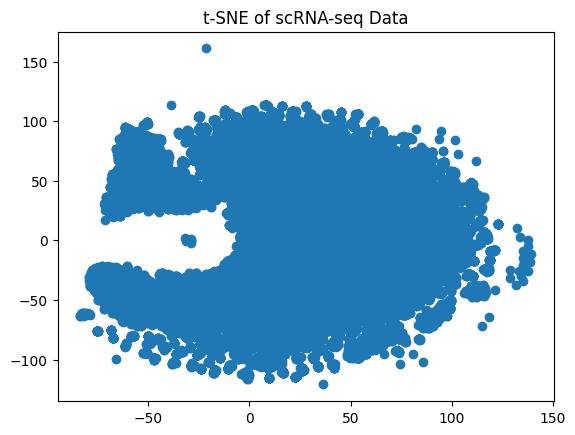

In [16]:
# t-SNE
tsne = TSNE(n_components=2, perplexity=10)
tsne_result = tsne.fit_transform(scaled_data)

# Visualize
plt.scatter(tsne_result[:,0], tsne_result[:,1])
plt.title("t-SNE of scRNA-seq Data")
plt.show()

**UMAP**

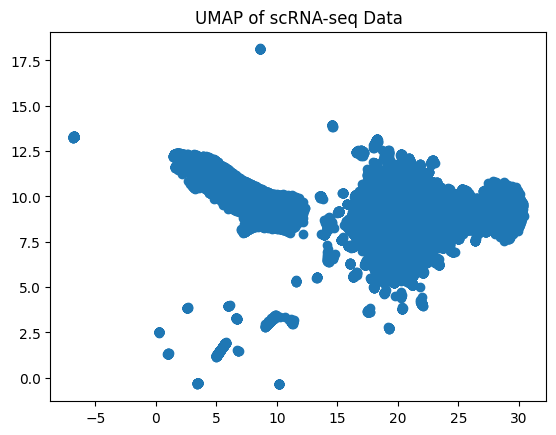

In [7]:
# UMAP
reducer = umap.UMAP()
umap_result = reducer.fit_transform(scaled_data)

# Visualize
plt.scatter(umap_result[:,0], umap_result[:,1])
plt.title("UMAP of scRNA-seq Data")
plt.show()

## Clustering

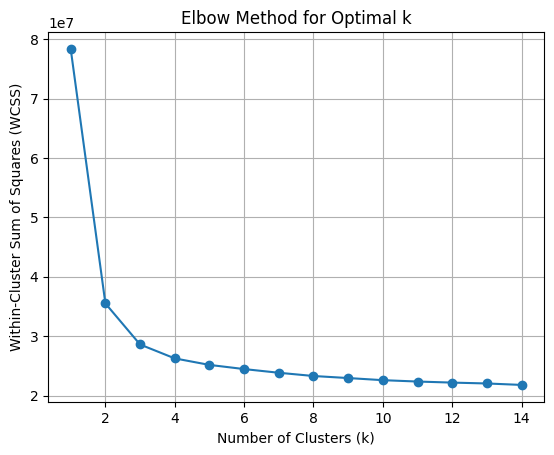

In [8]:
# Elbow plot
inertias = []
for k in range(1, 15):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_data)
    inertias.append(kmeans.inertia_)

plt.plot(range(1, 15), inertias, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.title('Elbow Method for Optimal k')
plt.grid(True)
plt.show()

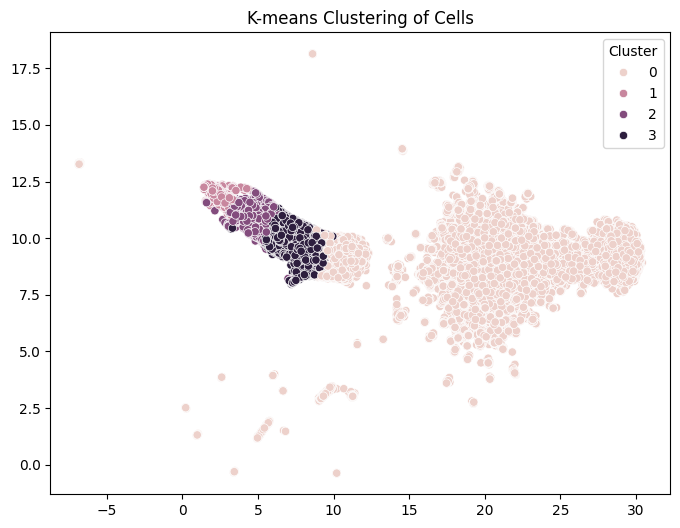

In [9]:
# K-means clustering (try different values of k)
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(scaled_data)

# Plot with cluster labels
plt.figure(figsize=(8,6))
sns.scatterplot(x=umap_result[:,0], y=umap_result[:,1], hue=clusters)
plt.title("K-means Clustering of Cells")
plt.legend(title='Cluster')
plt.show()

## Trajectory Inference

In [ ]:
from sklearn.neighbors import NearestNeighbors
import networkx as nx
from scipy.sparse.csgraph import minimum_spanning_tree

embedding = umap_result # use UMAP reduction generated earlier


# KNN Graph
knn = NearestNeighbors(n_neighbors=30).fit(embedding)
distances, indices = knn.kneighbors(embedding)

G = nx.Graph()
G.add_nodes_from(range(len(embedding)))  # ensure all cells are included
for i, neighbors in enumerate(indices):
    for j in neighbors:
        dist = np.linalg.norm(embedding[i] - embedding[j])
        G.add_edge(i, j, weight=dist)





# Compute pseudotime using min. spanning tree
pseudotime_full = {}

for component in nx.connected_components(G): # compute for fully connected components only
    root = min(component, key=lambda x: embedding[x, 0])  # set root as smallest PC1
    sub_mst = nx.minimum_spanning_tree(G.subgraph(component))
    times = nx.single_source_dijkstra_path_length(sub_mst, root) # use Djikstra's algorithm to find shortest path
    pseudotime_full.update(times)

pseudotime_array = np.array([pseudotime_full.get(i, np.nan) for i in range(len(embedding))])


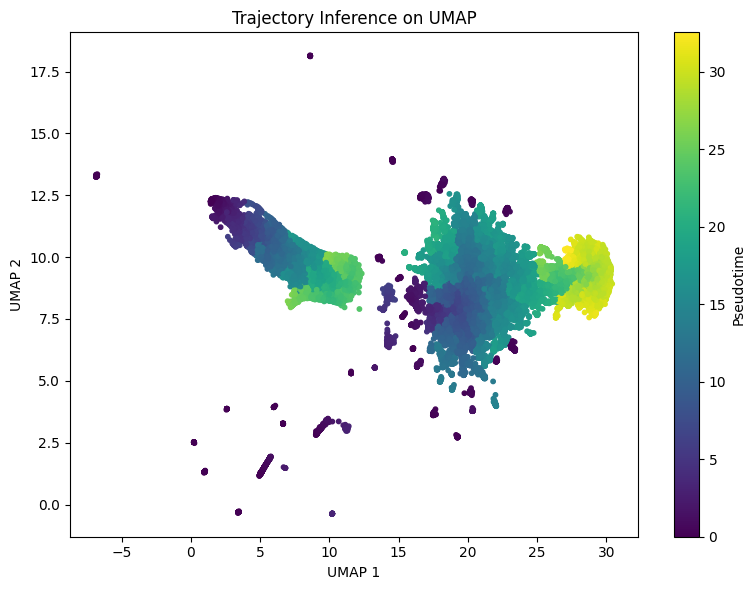

In [24]:
# Plot
plt.figure(figsize=(8, 6))
plt.scatter(embedding[:, 0], embedding[:, 1], c=pseudotime_array, cmap='viridis', s=10)
plt.colorbar(label='Pseudotime')
plt.title('Trajectory Inference on UMAP')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.tight_layout()
plt.show()